In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

base_path = "Daten"

all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gravity = pd.read_csv(os.path.join(folder_path, "Gravity.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gravity["Sensor"] = "Gravity"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gravity, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)



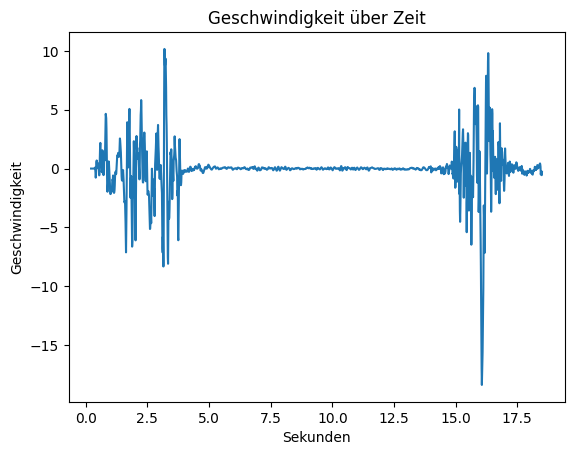

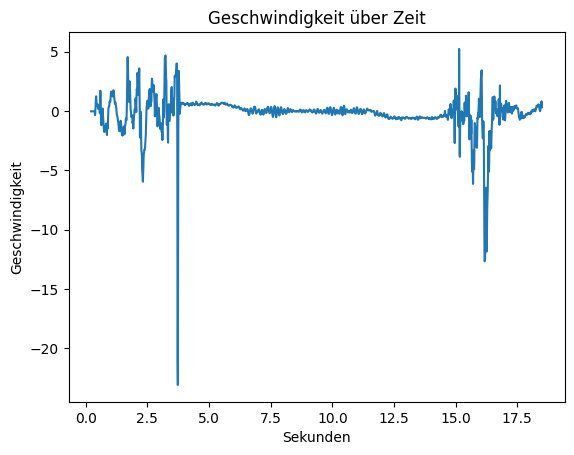

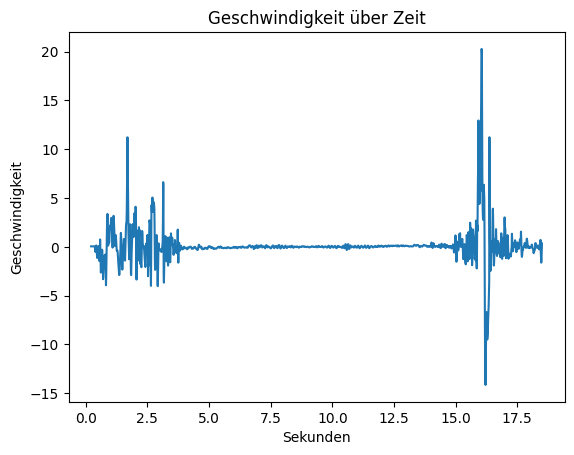

In [4]:
speed = final_df[(final_df["Sensor"] == "Accelerometer") & (final_df['ID'] == 1)]

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.plot(speed['seconds_elapsed'], speed["x"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["y"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["z"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit")
plt.show()